# Mini-Projeto MNIST - Classificação de Dígitos Manuscritos

**Análise Preditiva com Python - Módulo 2**

Pipeline ponta a ponta de Machine Learning para classificacao multiclasse de dígitos manuscritos (0-9) utilizando o dataset MNIST.

## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [ ]:
# Bibliotecas para manipulação de dados e visualização
import numpy as np
import matplotlib.pyplot as plt

# Função do scikit-learn para baixar o dataset MNIST diretamente do OpenML
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")

# fetch_openml carrega o dataset mnist_784 (70.000 imagens 28x28 = 784 pixels)
# as_frame=False retorna arrays numpy ao em vez de DataFrame pandas
# data_home="./data" salva o dataset localmente no projeto
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto", data_home="./data")
print("Finalizou o processo de baixar o dataset MNIST!")

# Separar features (X) e labels (y)
# X contêm os 784 pixels de cada imagem (vetorizado)
# y contêm o rótulo do dígito (0-9), convertido de string para inteiro
X, y = mnist.data, mnist.target.astype(int)

# Exibir dimensionalidade para comprovar a estrutura dos dados
print(f"Dimensionalidade de X: {X.shape}")
print(f"Dimensionalidade de y: {y.shape}")
print(f"Total de amostras: {X.shape[0]}")
print(f"Total de features (pixels): {X.shape[1]}")
print(f"Formato de cada imagem: 28x28 = {28*28} pixels")
print(f"Valores únicos de y: {np.unique(y)}")

Baixando o dataset MNIST...
Finalizou o processo dé baixar o dataset MNIST!
Dimensionalidade de X: (70000, 784)
Dimensionalidade de y: (70000,)
Total de amostras: 70000
Total de features (pixels): 784
Formato de cada imagem: 28x28 = 784 pixels
Valores únicos de y: [0 1 2 3 4 5 6 7 8 9]


In [2]:
# Estatísticas dos pixels - comprovação numérica da escala 0-255
print(f"Valor mínimo de pixel: {X.min():.0f}")
print(f"Valor máximo de pixel: {X.max():.0f}")
print(f"Valor média de pixel: {X.mean():.2f}")
print(f"Desvio padrão dos pixels: {X.std():.2f}")

# Verificar a integridade dos dados (valores nulos ou negativos)
print(f"Existem valores nulos? {np.isnan(X).any()}")
print(f"Existem valores negativos? {(X < 0).any()}")

# Verificar se o dataset é balanceado entre as classes
unique, counts = np.unique(y, return_counts=True)
print(f"\nBalanceamento das classes:")
print(f"  Minimo de amostras por classe: {counts.min()} (dígito {unique[counts.argmin()]})")
print(f"  Maximo de amostras por classe: {counts.max()} (dígito {unique[counts.argmax()]})")
print(f"  Diferença máxima entre classes: {counts.max() - counts.min()} amostras")

Valor mínimo de pixel: 0
Valor máximo de pixel: 255
Valor média de pixel: 33.39
Desvio padrão dos pixels: 78.65
Existem valores nulos? False
Existem valores negativos? False

Balanceamento das classes:
  Minimo de amostras por classe: 6313 (dígito 5)
  Maximo de amostras por classe: 7877 (dígito 1)
  Diferença máxima entre classes: 1564 amostras


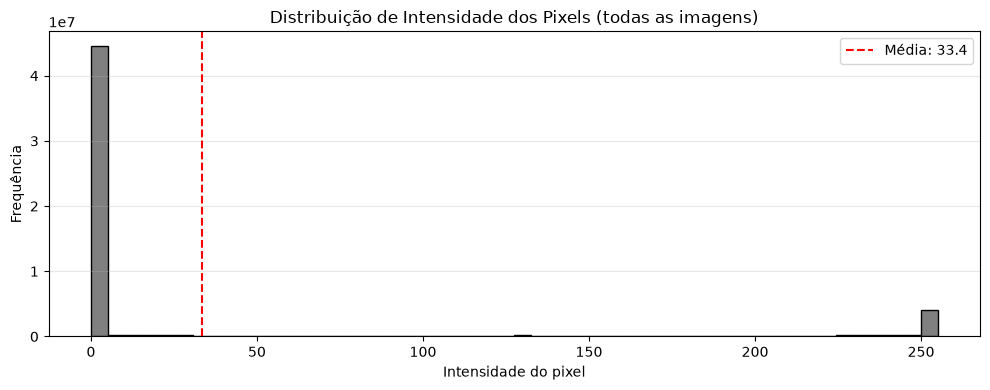

A maioria dos pixels é próxima de 0 (fundo preto das imagens).
Isso indica que as imagens são esparsas - o dígito ocupa apenas uma parte da área 28x28.


In [3]:
# Histograma de intensidade dos pixels
# Achatamos todas as imagens em um único vetor para analisar a distribuição global
plt.figure(figsize=(10, 4))
plt.hist(X.flatten(), bins=50, color="gray", edgecolor="black")
plt.xlabel("Intensidade do pixel")
plt.ylabel("Frequência")
plt.title("Distribuição de Intensidade dos Pixels (todas as imagens)")

# Linha vertical indicando a média global dos pixels
plt.axvline(X.mean(), color="red", linestyle="--", label=f"Média: {X.mean():.1f}")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretação do histograma
print("A maioria dos pixels é próxima de 0 (fundo preto das imagens).")
print("Isso indica que as imagens são esparsas - o dígito ocupa apenas uma parte da área 28x28.")

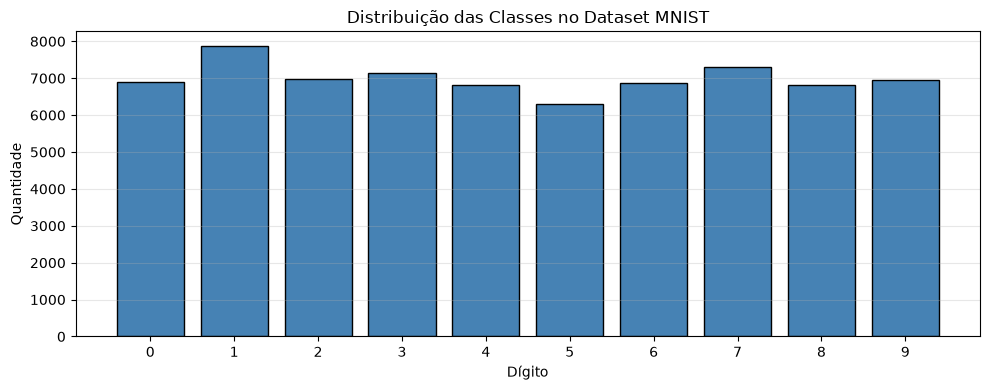

  Dígito 0: 6903 amostras (9.9%)
  Dígito 1: 7877 amostras (11.3%)
  Dígito 2: 6990 amostras (10.0%)
  Dígito 3: 7141 amostras (10.2%)
  Dígito 4: 6824 amostras (9.7%)
  Dígito 5: 6313 amostras (9.0%)
  Dígito 6: 6876 amostras (9.8%)
  Dígito 7: 7293 amostras (10.4%)
  Dígito 8: 6825 amostras (9.8%)
  Dígito 9: 6958 amostras (9.9%)


In [4]:
# Gráfico de barras mostrando a quantidade de amostras por classe
# Valores únicos e suas contagens já foram calculados na célula anterior
plt.figure(figsize=(10, 4))
plt.bar(unique, counts, color="steelblue", edgecolor="black")
plt.xlabel("Dígito")
plt.ylabel("Quantidade")
plt.title("Distribuição das Classes no Dataset MNIST")
plt.xticks(unique)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Exibir a quantidade exata de amostras por classe
for dígito, qtd in zip(unique, counts):
    pct = qtd / len(y) * 100
    print(f"  Dígito {dígito}: {qtd} amostras ({pct:.1f}%)")

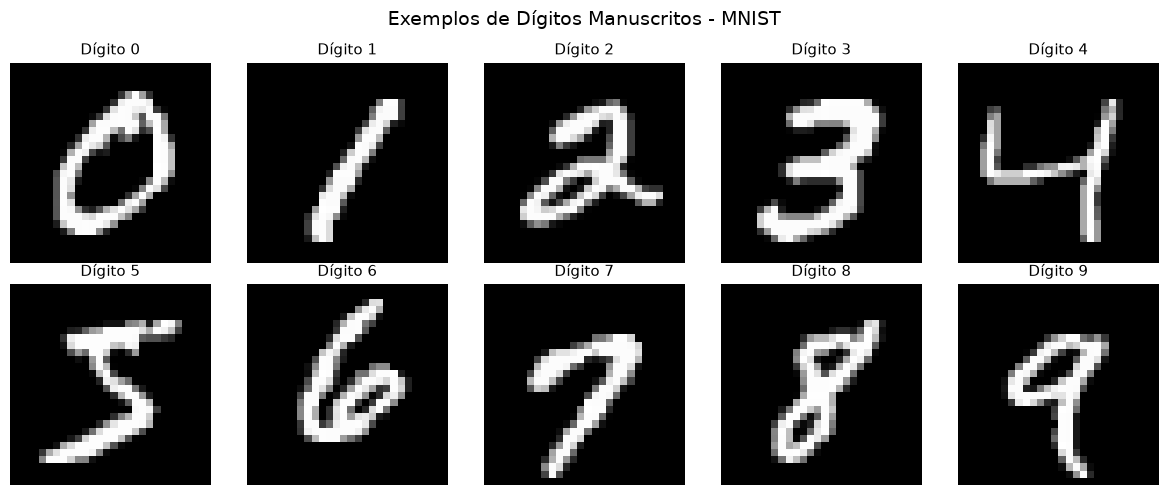

In [5]:
# Grade visual 2x5 com um exemplo de cada dígito (0-9)
# Usamos subplots para criar uma grade de 2 linhas x 5 colunas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Exemplos de Dígitos Manuscritos - MNIST", fontsize=14)

# Para cada dígito, encontramos a primeira ocorrência no dataset
for i in range(10):
    ax = axes[i // 5, i % 5]  # Posição no grid: linha = i//5, coluna = i%5
    idx = np.where(y == i)[0][0]  # Primeiro índice onde y == i
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")  # Reshape de 784 para 28x28
    ax.set_title(f"Dígito {i}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

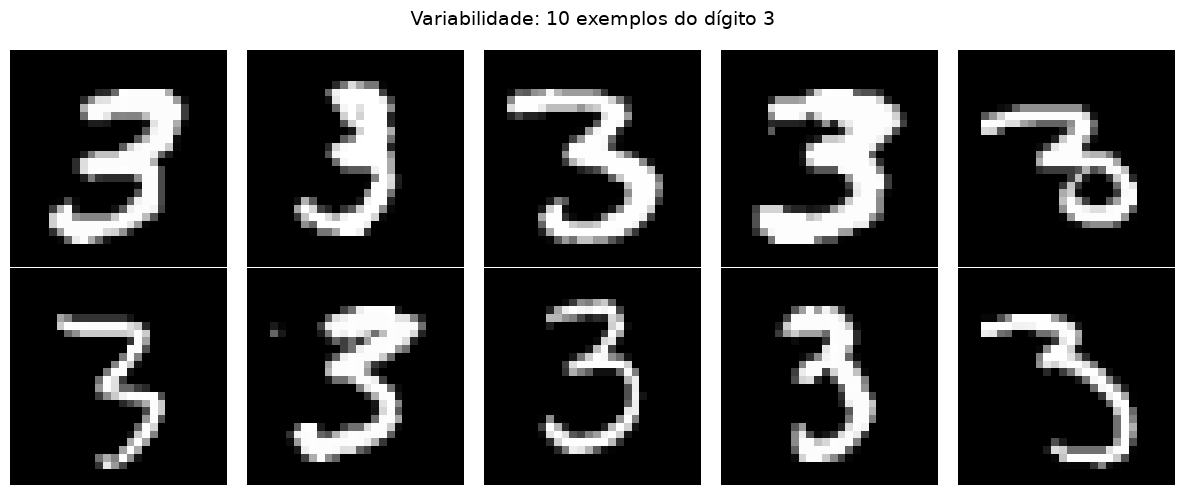

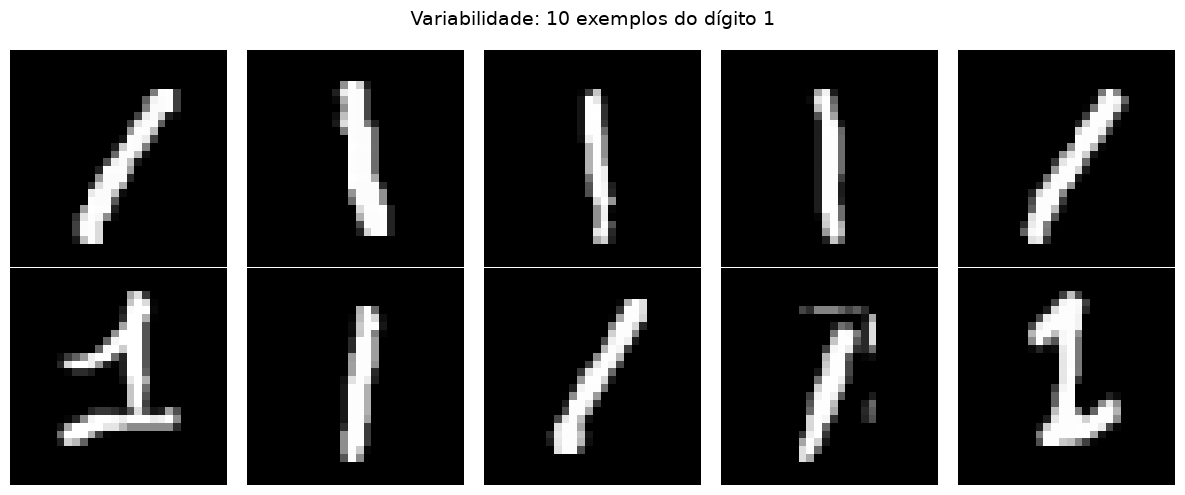

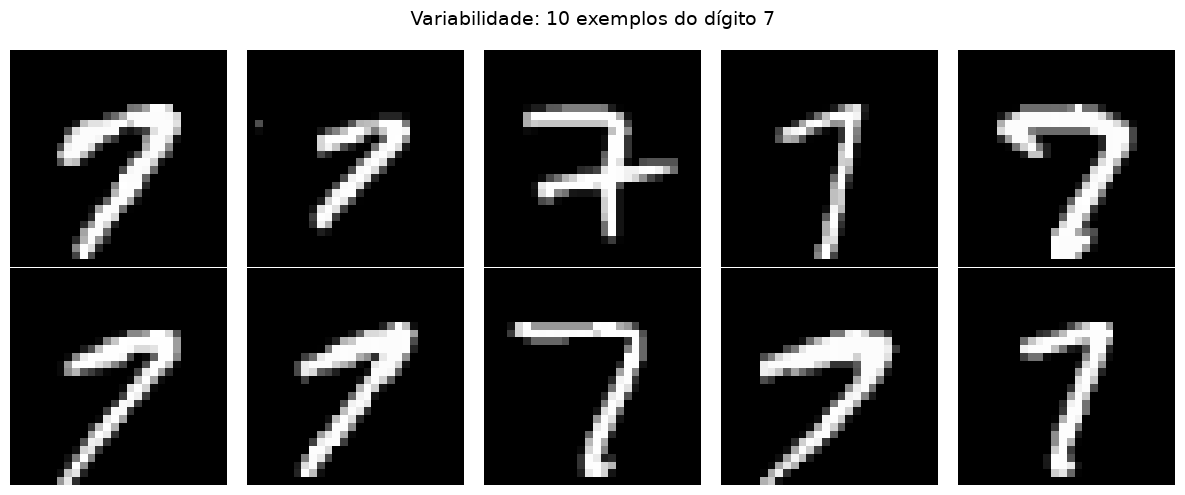

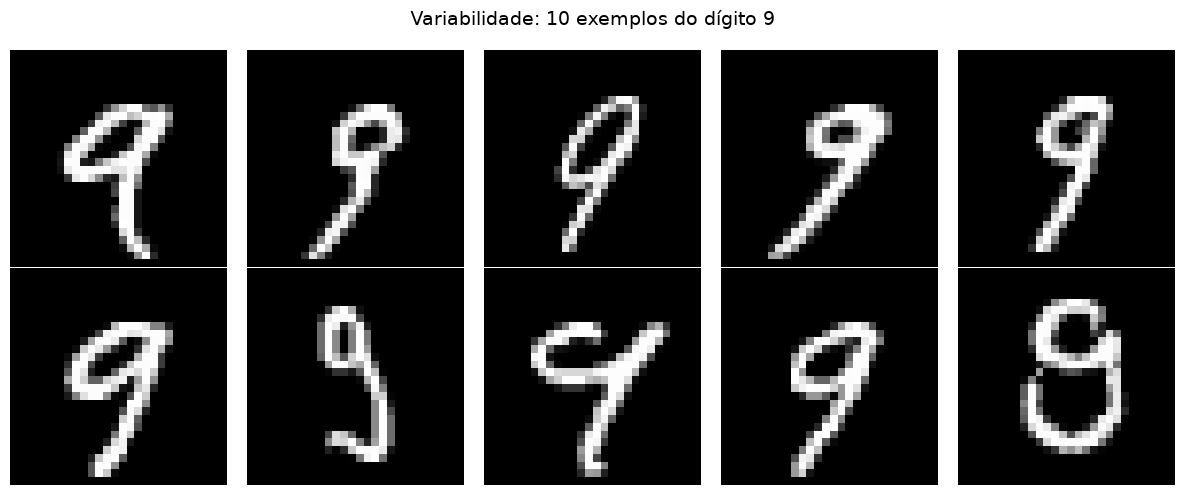

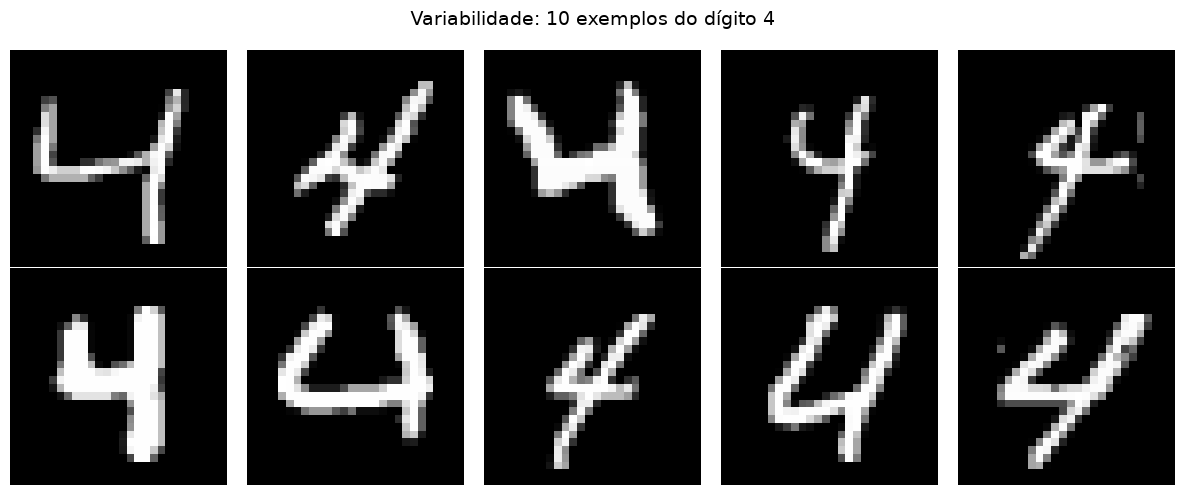

In [6]:
# Variabilidade intra-classe: mostrar que o mesmo dígito varia entre escritores
# Selecionamos 5 dígitos diferentes e mostramos 10 exemplos de cada
dígitos_exemplo = [3, 1, 7, 9, 4]

for dígito in dígitos_exemplo:
    # Coletar os primeiros 10 índices deste dígito
    índices = np.where(y == dígito)[0][:10]
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f"Variabilidade: 10 exemplos do dígito {dígito}", fontsize=14)
    
    for i in range(10):
        ax = axes[i // 5, i % 5]
        ax.imshow(X[índices[i]].reshape(28, 28), cmap="gray")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

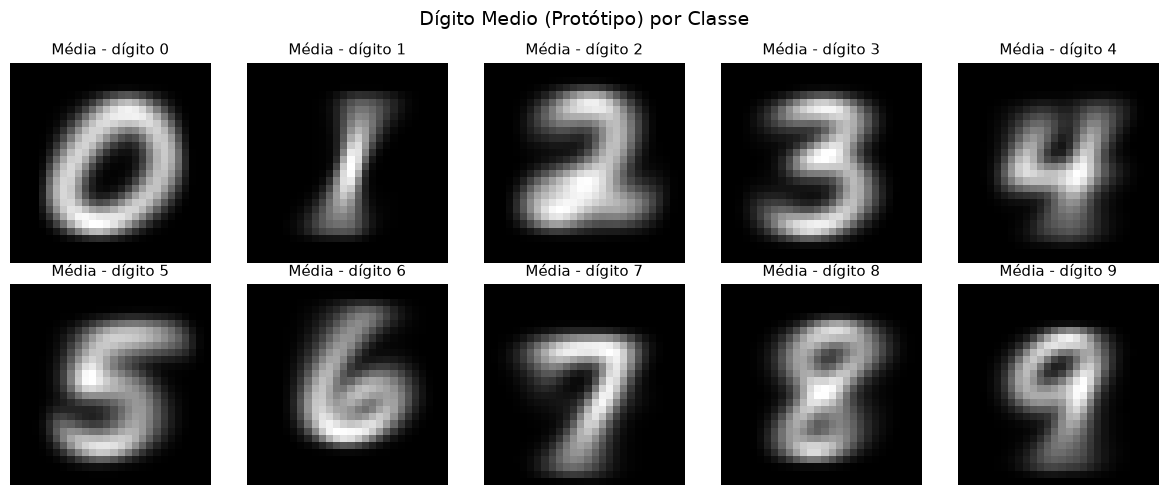

Nota: os protótipos médias dos dígitos 4 e 9 são visualmente similares,
o que justifica por que modelos frequentemente confundem essas classes.


In [7]:
# Dígito média (protótipo) por classe
# Calculamos a média pixel a pixel de todas as imagens de cada dígito
# Isso cria uma "imagem média" que representa o protótipo de cada classe
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Dígito Medio (Protótipo) por Classe", fontsize=14)

for i in range(10):
    # Filtra todas as imagens do dígito i e calcula a média ao longo do eixo 0
    média = X[y == i].mean(axis=0).reshape(28, 28)
    ax = axes[i // 5, i % 5]
    ax.imshow(média, cmap="gray")
    ax.set_title(f"Média - dígito {i}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Observação sobre confusão entre classes
print("Nota: os protótipos médias dos dígitos 4 e 9 são visualmente similares,")
print("o que justifica por que modelos frequentemente confundem essas classes.")

### Interpretação da Estrutura dos Dados

- **Escala de intensidade**: Os pixels variam de 0 a 255 (comprovado acima), representando tons de cinza em 8 bits. A média global é baixa, indicando predominância de pixels escuros (fundo preto).
- **Representação vetorial**: Cada imagem 28x28 pixels e achatada em um vetor de 784 dimensões, onde cada posição corresponde a um pixel. Essa representação é necessária para algoritmos de Machine Learning que recebem dados tabulares.
- **Balanceamento**: O dataset e relativamente balanceado. A diferença máxima entre classes é pequena (~1.4%), indicando que nenhum dígito é sub-representado.
- **Esparsidade**: O histograma mostra que a maioria dos pixels é próxima de 0 (fundo), confirmando que o dígito ocupa apenas uma área parcial da imagem 28x28.
- **Variabilidade intra-classe**: Os exemplos mostram que o mesmo dígito varia significativamente entre escritores diferentes. Isso torna o problema desafiador - o modelo precisa aprender a abstrair o conceito do dígito independente do estilo de escrita.
- **Protótipos**: A média das imagens por classe revela que certos dígitos (como 4 e 9) tem representações médias visualmente similares.

## Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

In [8]:
from sklearn.model_selection import train_test_split

# Divisão estratificada: 70% treino, 10% validação, 20% teste
# Primeiro separamos 80% treino+validação e 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Depois separamos 70% treino e 10% validação do restante
# (0.125 de 80% = 10% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(y)*100:.1f}%)")

# Verificar estratificação
print("\nDistribuição por classe no treino:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for digito, qtd in zip(unique_train, counts_train):
    pct = qtd / len(y_train) * 100
    print(f"  Dígito {digito}: {qtd} ({pct:.1f}%)")

Treino:    49000 amostras (70.0%)
Validação: 7000 amostras (10.0%)
Teste:     14000 amostras (20.0%)

Distribuição por classe no treino:
  Dígito 0: 4832 (9.9%)
  Dígito 1: 5514 (11.3%)
  Dígito 2: 4893 (10.0%)
  Dígito 3: 4999 (10.2%)
  Dígito 4: 4777 (9.7%)
  Dígito 5: 4419 (9.0%)
  Dígito 6: 4813 (9.8%)
  Dígito 7: 5105 (10.4%)
  Dígito 8: 4777 (9.7%)
  Dígito 9: 4871 (9.9%)


In [9]:
# Normalização: escalonamento dos pixels para a escala [0, 1]
# Dividimos todos os valores por 255.0 (valor máximo de pixel)
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

# Comprovar que a normalização funcionou
print("Antes da normalização:")
print(f"  Mínimo: {X_train.min():.0f}, Máximo: {X_train.max():.0f}, Média: {X_train.mean():.2f}")

print("\nDepois da normalização:")
print(f"  Mínimo: {X_train_norm.min():.4f}, Máximo: {X_train_norm.max():.4f}, Média: {X_train_norm.mean():.4f}")

Antes da normalização:
  Mínimo: 0, Máximo: 255, Média: 33.40

Depois da normalização:
  Mínimo: 0.0000, Máximo: 1.0000, Média: 0.1310


In [10]:
# Verificar que os conjuntos estão isolados (sem vazamento de dados)
# Comparar médias por classe entre treino e teste
print("Média de pixels por dígito (treino vs teste):")
header = "Dígito" + " " * 5 + "Treino" + " " * 5 + "Teste" + " " * 5 + "Diferença"
print(header)
print("-" * 42)
for digito in range(10):
    media_train = X_train_norm[y_train == digito].mean()
    media_test = X_test_norm[y_test == digito].mean()
    diff = abs(media_train - media_test)
    print(f"  {digito:<8} {media_train:>8.4f} {media_test:>8.4f} {diff:>8.4f}")

print("\nAs médias são muito próximas, confirmando que a estratificação funcionou.")

Média de pixels por dígito (treino vs teste):
Dígito     Treino     Teste     Diferença
------------------------------------------
  0          0.1732   0.1731   0.0001
  1          0.0761   0.0758   0.0003
  2          0.1494   0.1484   0.0010
  3          0.1421   0.1399   0.0022
  4          0.1214   0.1219   0.0005
  5          0.1290   0.1297   0.0007
  6          0.1384   0.1383   0.0001
  7          0.1150   0.1144   0.0006
  8          0.1501   0.1514   0.0013
  9          0.1231   0.1220   0.0011

As médias são muito próximas, confirmando que a estratificação funcionou.


### Justificativa da Normalização

A normalização divide os pixels por 255.0, escalonando os valores para o intervalo [0, 1]. Isso é essencial porque:

1. **Convergência de modelos lineares**: Algoritmos como MLP utilizam gradiente descendente; valores na escala original (0-255) causam gradientes instáveis e convergência lenta.
2. **Distâncias métricas**: KNN e SVM com kernel RBF dependem de distâncias euclidianas. Sem normalização, features com maior escala dominariam a métrica.
3. **Regularização**: Modelos com termos de regularização (L1/L2) funcionam melhor quando todas as features estão na mesma escala.

A divisão 70/10/20 com estratificação garante que todas as classes estejam representadas proporcionalmente em cada conjunto, evitando vieses na avaliação.